In [1]:
import modules.data as d
import modules.model as m
import modules.train as t
import modules.utils as u

import torch
import torch.nn as nn
from pathlib import Path

# dataset dir
datasets = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')

# get device
device, generator = u.Devices().auto_set_device()

# get data
data = d.Data(
    # datasets
    tcga_project = 'TCGA-BRCA',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',

    # dirs
    tcga_dir = datasets / 'tcga',
    relation_filepath = datasets / 'other/relation_ohe.csv',
    
    # col, filter
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Metastatic']},
    max_subset=120,
)

*** Device() ***
device = cuda:2

**** Data() ****
log0_method      log1p            str
class_weights    (6,)             Tensor (cuda:2)
gene_counts      (4383, 567)      DataFrame
metadata         (567, 3)         DataFrame
relation         (32798, 18)      DataFrame
node_id_map      4383             dict
masks            305              list
X                (567, 4383, 1)   Tensor (cuda:2)
y                (567, 6)         Tensor (cuda:2)
y_labels         6                list
num_samples      567              int
num_nodes        4383             int
num_features     1                int
num_labels       6                int
num_masks        305              int



---

In [2]:
import pandas as pd
import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from pathlib import Path
from tqdm import tqdm

# typing
from pandas import DataFrame
from torch import Tensor, Generator
from torch.nn.modules.loss import _Loss
from torch.utils.data import DataLoader, Dataset, random_split
from typing import Literal, Callable


from modules.utils import vprint

In [3]:
class Loader():
    def __init__(self, X:Tensor, y:Tensor, generator:Generator, batch_size:int=16, val_size:int=0.15, test_size:int=0.15):
        # format Xy as dataset
        self.dataset = self.CustomDataset(X, y)

        # get split sizes
        val_size = int(val_size * len(self.dataset))
        test_size = int(test_size * len(self.dataset))
        train_size = int(len(self.dataset) - val_size - test_size)

        # train test split
        train_dataset, val_dataset, test_dataset = random_split(self.dataset, [train_size, val_size, test_size], generator=generator)

        # get dataloaders
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, generator=generator)
        self.test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=generator)

        # get class_weights
        self.class_weights = y.shape[0]/y.sum(dim=0)

    class CustomDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
        

In [17]:
class Trainer():
    def __init__(self, model, loader:Loader, num_epochs:int, loss_fn:_Loss, optimizer_class:torch.optim.Optimizer=torch.optim.Adam, optimizer_kwargs:dict={}, report_metrics=['loss'], verbose:bool=False, autorun:bool=True):
        # assign inst vars
        self.model = model # should be a predefined model
        self.loader = loader
        self.num_epochs = num_epochs
        self.loss_fn = loss_fn
        self.optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
        self.report_metrics = report_metrics
        self.verbose = verbose
        
        if autorun:
            self.run()

    def run(self):
        # verbose, use tqdm
        if self.verbose == True:
            pbar = tqdm(range(self.num_epochs))
        else:
            pbar = range(self.num_epochs)

        # train, val loop
        self.dev_metrics = {}

        for epoch in pbar:
            # training
            train_metrics = self._train_model(self.loader.train_loader)

            # validating
            val_metrics = self._eval_model(self.loader.val_loader)

            # record training/validation
            self.dev_metrics[epoch] = {'train': train_metrics, 'val': val_metrics}

            # get reports
            train_report = self._generate_report(train_metrics, self.report_metrics)
            val_report = self._generate_report(val_metrics, self.report_metrics)

            # update pbar with report
            if self.verbose == True:
                epoch_report = f'Epoch {epoch:<8}' + f'Train: {train_report}' + 8*' ' + f'Val: {val_report}'
                pbar.set_postfix_str(epoch_report)

        # test
        self.test_metrics = self._eval_model(self.loader.test_loader)

        # print test report
        if self.verbose == True:
            test_report = self._generate_report(self.test_metrics, self.report_metrics)
            tqdm.write(f'Test\t {test_report}\n')

    def _generate_report(self, metrics:dict, report_metrics:list):
        # generate report
        report = (4*' ').join(
            f'{metric}={metrics[metric]:<.4f}'
            for metric in report_metrics
            if metric in metrics
        )

        return report

    def _update_batch(self, batch:int, loss, X:Tensor, y:Tensor, out:Tensor):
        # increment batch, loss
        batch['batch'] += 1
        batch['loss'] += loss.item()

        # append inputs, outputs
        batch['X'].extend(X.detach().cpu().numpy())
        batch['y'].extend(y.detach().cpu().numpy())
        batch['out'].extend(y.detach().cpu().numpy())

        return batch

    def _train_model(self, dataloader:DataLoader):
        # set model to train
        self.model.train()

        # init batch trackers
        batch = {
            'batch':0,
            'len':len(dataloader),
            'loss':0,
            'X':[],
            'y':[],
            'out':[]
        }

        # iterate over data
        for X, y in dataloader:
            self.optimizer.zero_grad()

            # compute loss
            loss, out = self._compute_loss(X, y)
            
            # backprop
            loss.backward()
            self.optimizer.step()

            # update batch
            batch = self._update_batch(batch, loss, X, y, out)

        # get performance metrics
        metrics = self._compute_metrics(batch)

        return metrics
    
    def _eval_model(self, dataloader:DataLoader):
        # set model to eval
        self.model.eval()

        # init batch trackers
        batch = {
            'batch':0,
            'len':len(dataloader),
            'loss':0,
            'X':[],
            'y':[],
            'out':[]
        }

        # iterate over data
        with torch.no_grad():
            for X, y in dataloader:
                # compute loss, pred
                loss, out = self._compute_loss(X, y)

                # update batch
                batch = self._update_batch(batch, loss, X, y, out)

        # get performance metrics
        metrics = self._compute_metrics(batch)

        return metrics

    #### change in child objects if needed: ####

    def _compute_loss(self, X:Tensor, y:Tensor): # change in child
        # get model output
        out = self.model(X)

        # compute loss
        loss = self.loss_fn(out, y)

        return loss, out
    
    def _compute_metrics(self, batch:dict): # change in child
        # init
        metrics = {}

        # compute metrics
        metrics['loss'] = batch['loss']/batch['len']

        return metrics


In [18]:
loader = Loader(
    data.X,
    data.y,
    generator
)

model = m.MLPClassifier(
    data.num_nodes,
    data.num_labels,
    flatten=True
)

trainer = Trainer(
    model,
    loader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(data.class_weights),
    verbose=True,
    autorun=False
)

trainer.run()

100%|██████████| 10/10 [00:00<00:00, 28.27it/s, Epoch 9       Train: loss=0.4579        Val: loss=4.0986]

Test	 loss=3.2316



---

In [165]:
class Config():
    def __init__(self, name:str, configs:dict={}):
        # inst vars
        self.name = name
        self.configs = configs
        self.num_epochs = None
        self.loader = None
        self.model = {}
        self.trainer = {}

    def add(self, key:str, model_class:nn.Module, trainer_class:Trainer, model_kwargs:dict={}, trainer_kwargs:dict={}):
        _config = {
            'model_class':model_class,
            'model_kwargs':model_kwargs,
            'trainer_class':trainer_class,
            'trainer_kwargs':trainer_kwargs,
        }

        self.configs[key] = _config

    def run(self, num_epochs:int, loader:Loader):
        self.num_epochs = num_epochs

        # init models, trainers
        for key in self.configs:
            self.model[key] = self.configs[key]['model_class'](**self.configs[key]['model_kwargs'])
            self.trainer[key] = self.configs[key]['trainer_class'](
                model=self.model[key],
                loader=loader, # requires loader
                num_epochs=self.num_epochs,
                autorun=False,
                **self.configs[key]['trainer_kwargs']
            )

        # run pipeline
        self.out = self._pipeline(loader)

    #### change in child objects if needed: ####

    def _pipeline(self, loader:Loader): # change in child
        for key in self.trainer:
            self.trainer[key].run()

In [257]:
model_config = None
model_config = Config(name='model')

model_config.add(
    key='classifier',
    model_class=m.MLPClassifier,
    model_kwargs={
        'in_features':data.num_nodes,
        'out_features':data.num_labels,
        'flatten':True,
    },
    trainer_class=Trainer,
    trainer_kwargs={
        'loss_fn':nn.CrossEntropyLoss(data.class_weights),
        'verbose':False,
    }
)

model_config.run(10, loader)

---

In [195]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [273]:
class Experiment():
    def __init__(self, num_trials:int, num_epochs:int, X:Tensor, y:Tensor, generator:Generator, batch_size:int=16, val_size:int=0.15, test_size:int=0.15):
        # inst vars
        self.num_trials = num_trials
        self.num_epochs = num_epochs
        self.X = X
        self.y = y
        self.generator = generator
        self.batch_size = batch_size
        self.val_size = val_size
        self.test_size = test_size

        # init configs
        self.configs = {}

    def add_config(self, _config:Config):
        self.configs[_config.name] = _config

    def run_experiment(self, comment:str=None, verbose:bool=True):
        # make folder
        self.folder = self._get_folder(comment)

        # if verbose, use tqdm
        if verbose == True:
            pbar_trials = tqdm(range(self.num_trials))
        else:
            pbar_trials = range(self.num_trials)

        # init trackers
        self.dev_metrics = {}
        self.test_metrics = {}
        
        # trial loop
        for trial in pbar_trials:

            # init loader per trial
            trial_loader = Loader(
                X=self.X,
                y=self.y,
                generator=self.generator,
                batch_size=self.batch_size,
                val_size=self.val_size,
                test_size=self.test_size,
            )

            # add trial to trackers
            self.dev_metrics[trial] = {}
            self.test_metrics[trial] = {}

            # for each config
            for config_name, _config in self.configs.items():
                
                # run config with trial loader
                _config.run(num_epochs = self.num_epochs, loader=trial_loader)

                # add trial config to trackers
                self.dev_metrics[trial][config_name] = {}
                self.test_metrics[trial][config_name] = {}

                # save model
                for key, model in _config.model.items():

                    # make config subfolder
                    subfolder = self.folder / f'{key}' / f'{config_name}'
                    subfolder.mkdir(parents=True, exist_ok=True)

                    # save
                    state_dict = model.state_dict()
                    torch.save(state_dict, subfolder / f'{config_name}_trial_{trial}.pth')

                # save metrics
                for key, trainer in _config.trainer.items():
                    self.dev_metrics[trial][config_name][key] = trainer.dev_metrics
                    self.test_metrics[trial][config_name][key] = trainer.test_metrics

            # convert to df
            self.dev_df = self._metrics_to_csv(self.dev_metrics, method='dev')
            self.test_df = self._metrics_to_csv(self.test_metrics, method='test')

        # get summary, plots
        self.summary = self._get_summary(self.test_df)
        self.figs = self._get_figs(self.dev_df, self.summary)

    def _metrics_to_csv(self, metrics:dict, method:Literal['dev','test']):
        # reshape rows
        if method == 'dev':
            # dev[trial][config][trainer][epoch][stage][metric] = value
            rows = [
                {
                    'trial': trial,
                    'config': config,
                    'trainer': trainer,
                    'epoch': epoch,
                    'stage': stage,
                    'metric': metric,
                    'value': value
                }
                for trial, configs in metrics.items()
                for config, trainers in configs.items()
                for trainer, epochs in trainers.items()
                for epoch, stages in epochs.items()
                for stage, metrics in stages.items()
                for metric, value in metrics.items()
            ]
        elif method == 'test':
            # test[trial][config][trainer][metric] = value
            rows = [
                {
                    'trial': trial,
                    'config': config,
                    'trainer': trainer,
                    'metric': metric,
                    'value': value
                }
                for trial, configs in metrics.items()
                for config, trainers in configs.items()
                for trainer, metrics in trainers.items()
                for metric, value in metrics.items()
            ]

        # convert to df, write to csv
        df = pd.DataFrame(rows)
        df.to_csv(self.folder / f'{method}.csv')

        return df
        
    def _get_summary(self, df:DataFrame):
        # ci helper fxn
        def _get_ci(series:pd.Series, confidence:float=0.95):
            n = series.count()
            mean = series.mean()
            sem = stats.sem(series, nan_policy='omit')
            ci = sem * stats.t.ppf((1 + confidence) / 2., n - 1)
            return ci
        
        # init dict
        summary = {}

        # group test df
        for trainer, group_df in df.groupby('trainer'):
            summary_df = group_df.groupby(['config','metric']).agg(
                mean=('value','mean'),
                std=('value','std'),
                ci=('value', _get_ci)
            ).reset_index()

            summary_df.to_csv(self.folder / 'summary.csv')
            summary[trainer] = summary_df

        return summary

    def _get_figs(self, df:DataFrame, summary:dict):
        # init
        figs = {}

        for trainer in df['trainer'].unique():
            figs[trainer] = {}
            df_trainer = df[df['trainer'] == trainer]
            summary_df = summary[trainer] # test vals

            for config in df_trainer['config'].unique():
                figs[trainer][config] = {}
                df_config = df_trainer[df_trainer['config'] == config]
                
                for metric in df_config['metric'].unique():
                    df_metric = df_config[df_config['metric'] == metric]
                    df_metric['stage'] = df_metric['stage'].replace({'train':'Training', 'val':'Validation'})
                    
                    # init figure
                    plt.figure(figsize=(8, 5))

                    # plot dev
                    sns.lineplot(data=df_metric, x='epoch', y='value', hue='stage')

                    # get test vals
                    test = summary_df[(summary_df['config'] == config) & (summary_df['metric'] == metric)] # get test vals
                    test_mean = test['mean'].values[0]
                    test_std = test['std'].values[0]

                    # plot test mean (line)
                    plt.axhline(
                        y=test_mean,
                        color='green',
                        linestyle='--',
                        label='Test'
                    )

                    # plot test std (area)
                    plt.fill_between(
                        x = df_metric['epoch'],
                        y1 = test_mean - test_std,
                        y2 = test_mean + test_std,
                        color='green',
                        alpha=0.2,
                    )

                    # add test label
                    plt.text(
                        x = max(df_metric['epoch']),
                        y = test_mean + 2*test_std,
                        s = f'{test_mean:.4f} ± {test_std:.4f}',
                        va = 'bottom',
                        ha = 'right',
                        color = 'green',
                        bbox = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='green', alpha=0.7)
                    )

                    # formatting
                    plt.title(f'{trainer.capitalize()} | {config.capitalize()} | {metric.capitalize()}')
                    plt.xlabel('Epoch')
                    plt.ylabel(metric.capitalize())
                    plt.legend(title='Stage')
                    plt.tight_layout()
                    
                    # make config subfolder
                    subfolder = self.folder / f'{trainer}' / f'{config}'
                    subfolder.mkdir(parents=True, exist_ok=True)

                    # Save the plot object (the current figure)
                    fig = plt.gcf()
                    figs[trainer][config][metric] = fig
                    fig.savefig(subfolder / f'{trainer}_{config}_{metric}.svg')
                    plt.close()
        
        return figs

    def _get_folder(self, comment:str=None):
        # get date, time
        date = datetime.now().strftime("%Y-%m-%d")
        time = datetime.now().strftime("%Hh%Mm%Ss").lower()

        # get dir name
        dir_name = f'{date}_{time}'

        if (comment != None) & (type(comment) == str): 
            dir_name = dir_name + f'_{comment}' # append comment if applicable

        # create folder
        folder = Path(f'./output/{dir_name}')
        folder.mkdir(parents=True, exist_ok=True)

        return folder
    

In [276]:
exp = Experiment(
    num_trials=3,
    num_epochs=10,
    X=data.X,
    y=data.y,
    generator=generator,
)

exp.add_config(model_config)

exp.run_experiment(comment='training_modules_test', verbose=True)

100%|██████████| 3/3 [00:00<00:00,  3.08it/s]


In [277]:
exp.configs['model'].model

{'classifier': MLPClassifier(
   (mlp): MLP(
     (model): Sequential(
       (0): Linear(in_features=4383, out_features=6, bias=False)
     )
   )
 )}

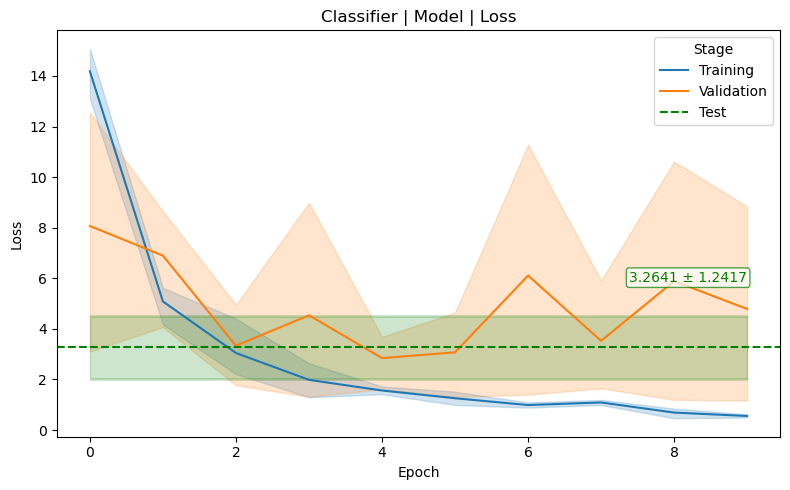

In [278]:
exp.figs['classifier']['model']['loss']

In [279]:
exp.dev_df

,trial,config,trainer,epoch,stage,metric,value
0,0,model,classifier,0,train,loss,14.386307
1,0,model,classifier,0,val,loss,16.555331
2,0,model,classifier,1,train,loss,4.173029
3,0,model,classifier,1,val,loss,7.965134
4,0,model,classifier,2,train,loss,2.211982
5,0,model,classifier,2,val,loss,4.952631
6,0,model,classifier,3,train,loss,1.295559
7,0,model,classifier,3,val,loss,8.986374
8,0,model,classifier,4,train,loss,1.724411
9,0,model,classifier,4,val,loss,3.681759
